## Implement a L-layer neural network
parameters: 
$$
W_1, b_1, W_2, b_2, ..., W_L, b_L
$$

hyperparameters: 
- learning rate
- number of iterations
- number of hidden layers (L)
- number of hidden units ($n_1, n_2, ..., n_L$)
- activation function in each layer

In [13]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
import scipy.io
from PIL import Image
from scipy import ndimage
from numpy import linalg as LA

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Data Exploration

In [32]:
def load_cat_data():
    train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


y = 1. It's a cat picture.


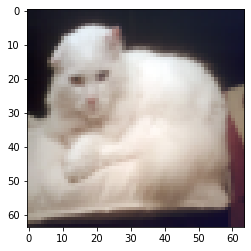

In [33]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_cat_data()
# Example of a picture
index = 13
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [34]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [35]:
# Reshape the training and test examples
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


# Simple Model

### Summary of learning process
- initialize parameters
- compute loss using forward function (store A, Z when forwarding)
- by doing back propagation, compute gradients of parameters with respect to calculated loss (using A,Z stored in forward propagation and params)
- compute cost function
- update parameters according to gradients calculated in back propagation (gradien descent)
- repeat steps 2 to 5 for the number of iterations

In [36]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        params = {}
        for l in range(1, self.L):
            if self.layer_dims[l-1]=="relu":
                params["W"+str(l)] = 2 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            elif self.layer_dims[l-1]=="sigmoid":
                params["W"+str(l)] = 1 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            else: 
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
                
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        return params

    def forward(self, X):
        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            if l!=self.L-1:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "relu")
            else:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "sigmoid")

        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        # dA[L-1] = -Y / A_L-1 + (1-Y) / (1-A_L-1)
        grads["dA"+str(self.L-1)] = np.divide(-Y, linear_actvs["A"+str(self.L-1)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(self.L-1)])
        # dZ[L-1] = dA[L-1] * G`
        grads["dZ"+str(self.L-1)] = np.multiply(grads["dA"+str(self.L-1)], self.act_func(linear_actvs["Z"+str(self.L-1)], func=self.actv_funcs[self.L-2], grad=True))

        # from l = L to l = 1
        for l in range(self.L-1, 0, -1):
            # dW[l] = 1/m * dZ[l] . A[l-1] 
            grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
            # db[l] = 1/m * np sum (dZ_l)
            grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
            if l!=1:
                # dA[l-1] = (W[l]).T . dZ[l]
                grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                # dZ[l-1] = dA[l-1] * g`
                grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-1], grad=True))

        return grads
    
    def compute_cost(self, Y, linear_actvs, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]

        cost = -1/m * (np.sum(np.multiply(Y, np.log(AL))) + np.sum(np.multiply((1-Y), np.log(1-AL))))
        cost = np.squeeze(cost)

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, is_debug=False):
        self.learning_rate = lr
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        
        for i in range(num_iterations):
            linear_actvs = self.forward(X)
            grads = self.backward(Y, linear_actvs)
            cost = self.compute_cost(Y, linear_actvs, is_debug)
            self.update_params(grads, lr)
            
            if i % 100 == 0 or i == num_iterations-1:
               print("cost after iteration ", i, ": ", cost)
        
            if i % 40 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                
        #return params

    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))
        
        linear_actvs = self.forward(X)
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                return 1/(1+np.exp(-Z))
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."
            
    def plot_lr(self):
        costs = np.squeeze(self.costs)
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(self.learning_rate))
        plt.show()

W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.7126996881076512
cost after iteration  100 :  0.6926276228629181
cost after iteration  200 :  0.650713623678998
cost after iteration  300 :  0.6439818805031423
cost after iteration  400 :  0.6411516999364297
cost after iteration  500 :  0.6370409563429403
cost after iteration  600 :  0.6311287073595443
cost after iteration  700 :  0.6233771589070397
cost after iteration  800 :  0.6122668221053342
cost after iteration  900 :  0.5975250195450761
cost after iteration  1000 :  0.5789538578475459
cost after iteration  1100 :  0.5583855213276406
cost after iteration  1200 :  0.53466536803774
cost after iteration  1300 :  0.5084170000829987
cost after iteration  1400 :  0.4727076590324959
cost after iteration  1500 :  0.43257036457842185
cost after iteration  1600 :  0.3908397026193877
cost after 

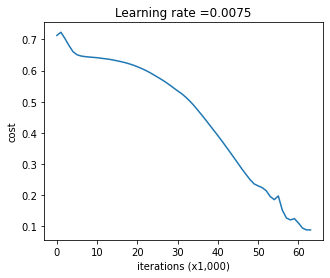

On the training set:
Accuracy: 0.9952153110047844
On the test set:
Accuracy: 0.76


In [41]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 2500, 0.0075)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

### Nan bug and overflow error:

example of overflow in last layer activations, so A[L-1] rounds to Zero and causes dividing by zero in backward function, 
which can be avoided if you use simplifed (simplified by calculus) formula:
dZ[L-1] = A[L-1] - Y 

**note that here L-1 is the last layer

In [164]:
def sigmoid(x):
    """
    Compute the sigmoid of x

    Arguments:
    x -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(x)
    """
    s = 1/(1+np.exp(-x))
    return s

sigmoid(-3022.56387003), np.exp(3022.56387003)

F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:11: RuntimeWarning: overflow encountered in exp
  # This is added back by InteractiveShellApp.init_path()
F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: overflow encountered in exp
  


(0.0, inf)

# L2 Regularization

In [205]:
import sys

In [237]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        params = {}
        for l in range(1, self.L):
            if self.layer_dims[l-1]=="relu":
                params["W"+str(l)] = 2 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            elif self.layer_dims[l-1]=="sigmoid":
                params["W"+str(l)] = 1 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            else: 
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
                
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        return params

    def forward(self, X, iter_num=-1):
        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        
        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            if l!=self.L-1:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "relu")
            else:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "sigmoid")
        
        """
        if iter_num == 2: 
            print("Z2 in iter 2", linear_actvs["Z"+str(2)])
            print("A2 in iter 2", linear_actvs["A"+str(2)])
        
        if iter_num == 3: 
            print("Z2 in iter 3", linear_actvs["Z"+str(2)])
            print("A2 in iter 3", linear_actvs["A"+str(2)])
        
        
        print("A1", linear_actvs["A"+str(1)])
        print("A2", linear_actvs["A"+str(2)])
        print("Z1", linear_actvs["Z"+str(1)])
        print("Z2", linear_actvs["Z"+str(2)])
        
        print("W1", self.params["W1"])
        print("b1", self.params["b1"])
        print("W2", self.params["W2"])
        print("b2", self.params["b2"])
        """
        
        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        """""
        # dA[L-1] = -Y / A_L-1 + (1-Y) / (1-A_L-1)
        grads["dA"+str(self.L-1)] = np.divide(-Y, linear_actvs["A"+str(self.L-1)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(self.L-1)])
        # dZ[L-1] = dA[L-1] * G`[L-1]
        grads["dZ"+str(self.L-1)] = np.multiply(grads["dA"+str(self.L-1)], self.act_func(linear_actvs["Z"+str(self.L-1)], func=self.actv_funcs[self.L-2], grad=True))
        """""
        
        # ***********
        # using the above equations, case of A[L-1] = 0 might have happend (because of large Z and using sigmoid and rounding number to 0 (overflow))
        # then using the above equation causes /0 error and creates Nan
        # to avoid that, use the simplified version:
        # dZ[L-1] = A[L-1] - Y
        grads["dZ"+str(self.L-1)] = linear_actvs["A"+str(self.L-1)] - Y
        
        # from l = L to l = 1
        for l in range(self.L-1, 0, -1):
            if self.regularization == "L2":
                # dW[l] = 1/m * dZ[l] . A[l-1] + lambda/m * W[l]
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T) + ((self.reg_param/m) * self.params["W"+str(l)])
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-1], grad=True))

            else:
                # dW[l] = 1/m * dZ[l] . A[l-1] 
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-1], grad=True))

        return grads
    
    def compute_cost(self, Y, linear_actvs, iter_num, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]

        """
        if np.isnan(np.sum(AL + Y)): 
            print("Nan found in iter ", iter_num)
            print("A3:", AL)
            print("A2", linear_actvs["A"+str(2)])
            print("A1", linear_actvs["A"+str(1)])
            
            # print("Z3", linear_actvs["Z"+str(3)])
            print("Z2", linear_actvs["Z"+str(2)])
            print("Z1", linear_actvs["Z"+str(1)])
            sys.exit()
        """
            
        
        cost = (-1/m) * (np.sum(np.multiply(Y, np.log(AL))) + np.sum(np.multiply((1-Y), np.log(1-AL)))) 
        
        #print(cost)
        
        if self.regularization== "L2":
            reg_cost = 0
            for l in range(self.L-1, 0, -1):
                reg_cost += np.sum(np.square(self.params['W'+str(l)]))

            cost = cost + self.reg_param/(2*m) * reg_cost
            cost = np.squeeze(cost)
        # else:

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, reg_param = 0, regularization = "", is_debug=False):
        self.reg_param = reg_param
        self.learning_rate = lr
        self.regularization = regularization
        
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        
        for i in range(num_iterations):
            
            # print("In forward, iteration number ", i)
            linear_actvs = self.forward(X, i)
            # print("In backward, iteration number ", i)
            grads = self.backward(Y, linear_actvs)
            #print("dW1", grads["dW1"])
            #print("db1", grads["db1"])
            #print("dW2", grads["dW2"])
            #print("db2", grads["db2"])
            
            cost = self.compute_cost(Y, linear_actvs, i, is_debug)
            self.update_params(grads, lr)
            
            if i % 1000 == 0 or i == num_iterations-1:
                print("cost after iteration ", i, ": ", cost)
                # print("iteratio {}, Linear activations: ".format(i), linear_actvs)
        
            if i % 1000 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                
        #return params

    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))
        
        linear_actvs = self.forward(X)
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                res = 1/(1+np.exp(-Z))
                return res
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."\
            
    def plot_lr(self):
        costs = np.squeeze(self.costs)
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(self.learning_rate))
        plt.show()

## Data

In [242]:
def predict_dec(model, X):
    # Predict using forward propagation and a classification threshold of 0.5
    linear_actvs = model.forward(X)
    al = linear_actvs["A"+str(model.L-1)]
    predictions = (al>0.5)
    return predictions

def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.show()

In [209]:
def load_2D_dataset():
    data = scipy.io.loadmat('datasets/2D_data.mat')
    train_X = data['X'].T
    train_Y = data['y'].T
    test_X = data['Xval'].T
    test_Y = data['yval'].T

    plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);
    
    return train_X, train_Y, test_X, test_Y

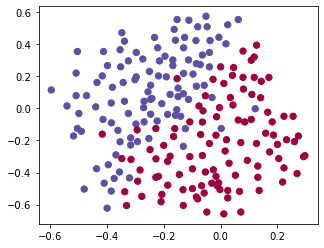

In [210]:
train_x, train_y, test_x, test_y = load_2D_dataset()

## No L2 regularization:

W 1  shape:  (20, 2)
b 1  shape:  (20, 1)
W 2  shape:  (3, 20)
b 2  shape:  (3, 1)
W 3  shape:  (1, 3)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.6865478300417903
cost after iteration  1000 :  0.23129157707749307
cost after iteration  2000 :  0.22812920667175185
cost after iteration  3000 :  0.22834101157778414
cost after iteration  4000 :  0.22176435433567018
cost after iteration  5000 :  0.21593651593422003
cost after iteration  6000 :  0.2118080852076466
cost after iteration  7000 :  0.20717035194667646
cost after iteration  8000 :  0.2023498448979817
cost after iteration  9000 :  0.19929637516026238
cost after iteration  10000 :  0.1947381139176824
cost after iteration  11000 :  0.18731081026338905
cost after iteration  12000 :  0.19412727257428655
cost after iteration  13000 :  0.19474089684133705
cost after iteration  14000 :  0.18884732742645147
cost after iteration  15000 :  0.18579883820151488
cost after iteration  16000 :  0.18468977720754629
cost after iteration  17000

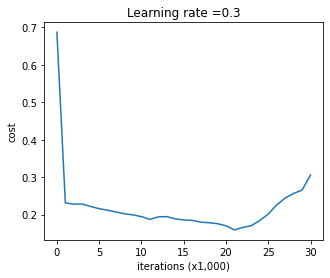

On the training set:
Accuracy: 0.8767772511848342
On the test set:
Accuracy: 0.9149999999999998


In [257]:
activation_funcs = ["relu", "relu", "sigmoid"]
dnn = DeepNN([train_x.shape[0], 20, 3, 1], activation_funcs)
dnn.train(train_x, train_y, 30000, 0.3)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_X, train_Y)
print ("On the test set:")
predictions_test = dnn.predict(test_X, test_Y)

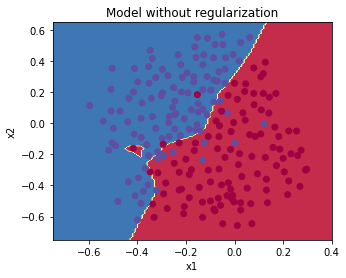

In [243]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(dnn, x.T), train_X, train_Y)

### Testing without L2 reg:

W 1  shape:  (20, 2)
b 1  shape:  (20, 1)
W 2  shape:  (3, 20)
b 2  shape:  (3, 1)
W 3  shape:  (1, 3)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.7393738820489378
cost after iteration  1000 :  0.24463640794480224
cost after iteration  2000 :  0.24232521314693278
cost after iteration  3000 :  0.24027446710344005
cost after iteration  4000 :  0.2385641424585761
cost after iteration  5000 :  0.2371172920175174
cost after iteration  6000 :  0.23531824410036586
cost after iteration  7000 :  0.23356591171797483
cost after iteration  8000 :  0.23151338057522233
cost after iteration  9000 :  0.2294637157936909
cost after iteration  10000 :  0.2276709749100245
cost after iteration  11000 :  0.22629338388012352
cost after iteration  12000 :  0.22523331017532525
cost after iteration  13000 :  0.22454939277365327
cost after iteration  14000 :  0.22397481558652688
cost after iteration  15000 :  0.22357128867297302
cost after iteration  16000 :  0.22330472374215762
cost after iteration  17000 

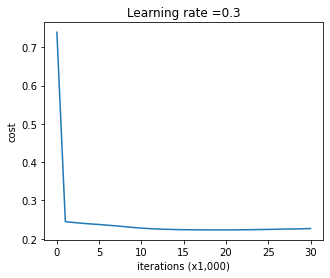

On the training set:
Accuracy: 0.9383886255924171
On the test set:
Accuracy: 0.9499999999999998


In [262]:
activation_funcs = ["relu", "relu", "sigmoid"]
dnn = DeepNN([train_x.shape[0], 20, 3, 1], activation_funcs)
dnn.train(train_x, train_y, 30000, 0.3, 0.2, "L2")

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_X, train_Y)
print ("On the test set:")
predictions_test = dnn.predict(test_X, test_Y)

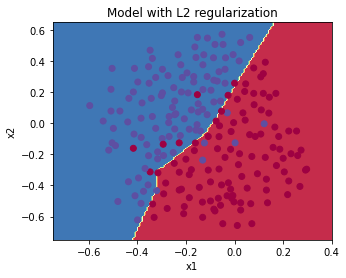

In [263]:
plt.title("Model with L2 regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(dnn, x.T), train_X, train_Y)

# Dropout Regularization

In [45]:
# Add later

# Early Stopping

In [46]:
# Add later

# Data Augmentation

y = 1. It's a cat picture.


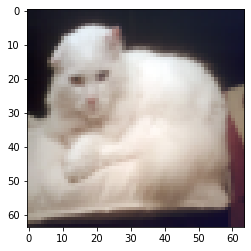

In [72]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()
# Example of a picture
index = 13
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

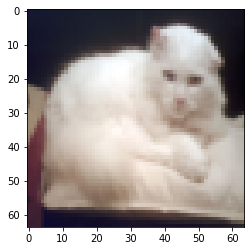

In [73]:
plt.imshow(np.flip(train_x_orig, 2)[index])

In [78]:
# Reshape the training and test examples
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

train_x_vertical_flip = np.flip(train_x_orig, 2)
train_x_vertical_flip_flatten = train_x_vertical_flip.reshape(train_x_vertical_flip.shape[0], -1).T

train_x_flatten = np.append(train_x_flatten, train_x_vertical_flip_flatten, axis=1)
train_y = np.append(train_y, train_y, axis=1)
# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 418)
test_x's shape: (12288, 50)


W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.7058450884230453
cost after iteration  100 :  0.6528112747807863
cost after iteration  200 :  0.6491262008708368
cost after iteration  300 :  0.6450322848551118
cost after iteration  400 :  0.639026732602155
cost after iteration  500 :  0.630830420013293
cost after iteration  600 :  0.6205846559292387
cost after iteration  700 :  0.6088415961411688
cost after iteration  800 :  0.5966021889669251
cost after iteration  900 :  0.5825070430204199
cost after iteration  1000 :  0.56246792292016
cost after iteration  1100 :  0.539417282631825
cost after iteration  1200 :  0.51582708253931
cost after iteration  1300 :  0.4909563012589768
cost after iteration  1400 :  0.46660318258205813
cost after iteration  1500 :  0.44159601394003717
cost after iteration  1600 :  0.4159178262083876
cost after ite

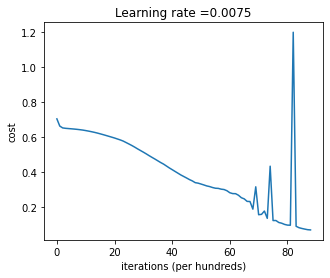

In [119]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 3500, 0.0075, reg_param=0.1)

# Plot learning curve (with costs)
costs = np.squeeze(dnn.costs)
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(dnn.learning_rate))
plt.show()

In [120]:
pred_train = dnn.predict(train_x, train_y)

Accuracy: 0.9952153110047844


In [121]:
pred_test = dnn.predict(test_x, test_y)

Accuracy: 0.76


# Gradient Checking

In [114]:
# Add later

# Mini Batch Gradient Descent

In [122]:
# a function to create leist of minibatches, then use this function in train function of model

# Momentum

In [123]:
# gradient descent with momentum

# RMSprop

# Adam optimization

# Learning rate Decay

# Appropiate SCALE to tune hyperparameters ? 

# Batch Normalization ****

# Multiclass classification, Softmax Regression